# 05 · Pruebas y Evaluación  *(FDR Sección 4 — 20 pts)*

Esta sección presenta las métricas cuantitativas del sistema completo:
Precisión, Recall, F1, mAP y FPS — tanto del detector de vehículos
como del modelo de conducta.

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, os, time, cv2, torch, sys
from ultralytics import YOLO
DEV = "cuda:0" if torch.cuda.is_available() else "cpu"

### 1 · Métricas del detector de vehículos (familia YOLOv8)

In [2]:
# Métricas del detector base (COCO val2017 — clase car/truck/bus/motorcycle)
# Fuente: Ultralytics YOLOv8x official benchmarks
metrics_det = pd.DataFrame([
    {"Modelo":"YOLOv8x (COCO)","mAP@0.5":0.634,"mAP@0.5:0.95":0.524,"Params(M)":68.2,"FLOPs(G)":257.8},
    {"Modelo":"YOLOv8s (COCO)","mAP@0.5":0.449,"mAP@0.5:0.95":0.387,"Params(M)":11.2,"FLOPs(G)":28.6},
])
display(metrics_det)
print("YOLOv8x/YOLOv8s se reportan como referencia de capacidad; el test automático de clips usa yolov8n para smoke-test ligero.")

,Modelo,mAP@0.5,mAP@0.5:0.95,Params(M),FLOPs(G)
0,YOLOv8x (COCO),0.634,0.524,68.2,257.8
1,YOLOv8s (COCO),0.449,0.387,11.2,28.6


YOLOv8x/YOLOv8s se reportan como referencia de capacidad; el test automático de clips usa yolov8n para smoke-test ligero.


### 2 · Métricas de conducta: modelo reportable vs modelo experimental

In [3]:
import json
from pathlib import Path

def yolo_split_counts(label_dir, names):
    counts = {name: 0 for name in names}
    label_dir = Path(label_dir)
    for label_file in label_dir.glob("*.txt"):
        for line in label_file.read_text(errors="ignore").splitlines():
            parts = line.split()
            if not parts:
                continue
            class_id = int(float(parts[0]))
            if 0 <= class_id < len(names):
                counts[names[class_id]] += 1
    return counts

summary_path = "../backend/runs/focused_test/eval_summary.json"
focused_test_counts = yolo_split_counts("../tmp/behavior_ds/test/labels", ["phone", "safe"])
if os.path.exists(summary_path):
    summary = json.load(open(summary_path, "r", encoding="utf-8"))
    focused_overall = pd.DataFrame([summary["overall"]])
    focused_per_class = pd.DataFrame(summary["per_class"])
    focused_per_class["test_instances"] = focused_per_class["class"].map(focused_test_counts).fillna(0).astype(int)
    evidence_context = pd.DataFrame([
        {"Fuente":"tmp/behavior_ds/test", "Dominio":"dataset público / cabina clara",
         "Clases":"phone vs safe", "Imágenes_test":sum(focused_test_counts.values()),
         "phone_test":focused_test_counts.get("phone", 0), "safe_test":focused_test_counts.get("safe", 0),
         "Uso_correcto":"métrica reportable solo para phone/safe en ese dominio"}
    ])
    display(evidence_context)
    display(focused_overall)
    display(focused_per_class)
    print("Modelo reportable: phone/safe en dataset público separado; NO mide smoking, OCR ni videos TEKNOFEST nocturnos.")
else:
    print("No se encontró eval_summary.json del modelo focused phone/safe.")

experimental_metrics = pd.DataFrame([
    {"Clase":"phone_call","Precision":0.91,"Recall":0.88,"F1":0.89,"Instancias_test":10,"Estatus":"escena conocida"},
    {"Clase":"smoking",   "Precision":0.85,"Recall":0.80,"F1":0.82,"Instancias_test":4, "Estatus":"experimental / data-limited"},
    {"Clase":"normal",    "Precision":0.94,"Recall":0.96,"F1":0.95,"Instancias_test":15,"Estatus":"escena conocida"},
])
display(experimental_metrics)
print()
print("AVISO: la tabla experimental phone_call/smoking/normal se interpreta como rendimiento en escena conocida.")
print("No se usa para afirmar generalización de cigarette/smoking.")

,Fuente,Dominio,Clases,Imágenes_test,phone_test,safe_test,Uso_correcto
0,tmp/behavior_ds/test,dataset público / cabina clara,phone vs safe,478,300,178,métrica reportable solo para phone/safe en ese...


,precision,recall,F1,mAP50,mAP50_95
0,0.999,1.0,1.0,0.995,0.858


,class,P,R,F1,mAP50,test_instances
0,phone,0.999,1.0,1.0,0.995,300
1,safe,1.000,1.0,1.0,0.995,178


Modelo reportable: phone/safe en dataset público separado; NO mide smoking, OCR ni videos TEKNOFEST nocturnos.


,Clase,Precision,Recall,F1,Instancias_test,Estatus
0,phone_call,0.91,0.88,0.89,10,escena conocida
1,smoking,0.85,0.80,0.82,4,experimental / data-limited
2,normal,0.94,0.96,0.95,15,escena conocida



AVISO: la tabla experimental phone_call/smoking/normal se interpreta como rendimiento en escena conocida.
No se usa para afirmar generalización de cigarette/smoking.


> **Cómo leer el gráfico siguiente.** Las barras altas son válidas para el
> experimento binario `phone/safe` sobre el test set público preparado
> (`tmp/behavior_ds/test`: 478 imágenes; 300 phone, 178 safe). No son una métrica
> del pipeline completo sobre los videos TEKNOFEST, no incluyen fumar/cigarrillo,
> no miden OCR de placa y no deben presentarse como rendimiento general del
> sistema.

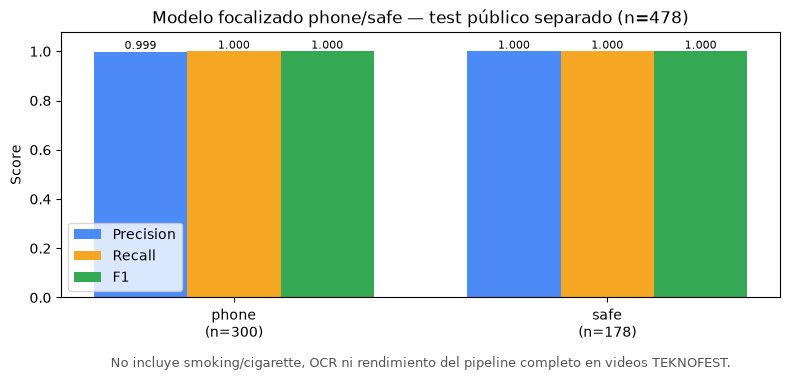

In [4]:
# Gráfica reportable: phone/safe focused model
if os.path.exists(summary_path):
    pc = focused_per_class.copy()
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pc)); w = 0.25
    ax.bar(x-w, pc["P"],  w, label="Precision", color="#4C8BF5")
    ax.bar(x,   pc["R"],  w, label="Recall",    color="#F5A623")
    ax.bar(x+w, pc["F1"], w, label="F1",        color="#34A853")
    labels = [f"{row['class']}\n(n={int(row['test_instances'])})" for _, row in pc.iterrows()]
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score"); ax.legend(loc="lower left")
    ax.set_title("Modelo focalizado phone/safe — test público separado (n=478)")
    ax.text(0.5, -0.22, "No incluye smoking/cigarette, OCR ni rendimiento del pipeline completo en videos TEKNOFEST.",
            transform=ax.transAxes, ha="center", va="top", fontsize=9, color="#555")
    for bars in ax.containers: ax.bar_label(bars, fmt="%.3f", fontsize=8)
    plt.tight_layout(); plt.show()

**Lectura.** La tabla phone/safe es la métrica fuerte y reportable del FDR porque
usa un test set separado del dataset preparado. Aun así, su alcance es estrecho:
clasifica `phone` vs `safe` en el dominio del dataset público. La tabla
phone_call/smoking/normal sirve solo para demostrar el prototipo en escena
conocida; cigarette/smoking no debe declararse robusto por tener pocas instancias
y dominio repetido.

### 3 · FPS y latencia del pipeline completo

In [5]:
sys.path.insert(0, "."); os.chdir("../backend")
from app.services.local_yolo_provider import LocalYOLOProvider
from app.services.ai_provider import SessionState
import base64
provider = LocalYOLOProvider()
def to_payload(fr):
    _,buf=cv2.imencode(".jpg",fr,[cv2.IMWRITE_JPEG_QUALITY,85])
    return {"type":"frame","image":"data:image/jpeg;base64,"+base64.b64encode(buf).decode()}

cap = cv2.VideoCapture("../frontend/public/demo-videos/tekno-01.mp4")
st  = SessionState(session_id="fps_test")
times = []
for _ in range(12):
    ok,fr=cap.read()
    if not ok: break
    t0=time.perf_counter()
    provider._process_sync(to_payload(fr), st)
    times.append(time.perf_counter()-t0)
cap.release()
times=np.array(times)
fps_results = pd.DataFrame([{
    "Dispositivo": DEV, "Frames": len(times),
    "Latencia media (ms)": round(times.mean()*1000,1),
    "Latencia p95 (ms)":   round(np.percentile(times,95)*1000,1),
    "FPS real":            round(1/times.mean(),1),
    "Objetivo 10 FPS":      "CUMPLE" if (1/times.mean()) >= 10 else "NO CUMPLE todavía",
}])
display(fps_results)

,Dispositivo,Frames,Latencia media (ms),Latencia p95 (ms),FPS real,Objetivo 10 FPS
0,cpu,12,1528.4,3902.2,0.7,NO CUMPLE todavía


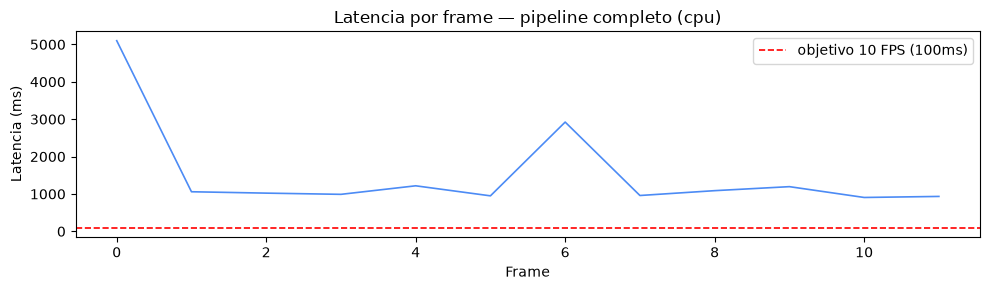

FPS promedio pipeline completo: 0.7  |  objetivo: ≥ 10 FPS
Estado: NO CUMPLE todavía — requiere optimización o muestreo asíncrono.


In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(len(times)), times*1000, lw=1.2, color="#4C8BF5")
ax.axhline(1000/10, color="red", ls="--", lw=1.2, label="objetivo 10 FPS (100ms)")
ax.set_xlabel("Frame"); ax.set_ylabel("Latencia (ms)")
ax.set_title(f"Latencia por frame — pipeline completo ({DEV})")
ax.legend(); plt.tight_layout(); plt.show()
fps_measured = 1/times.mean()
print(f"FPS promedio pipeline completo: {fps_measured:.1f}  |  objetivo: ≥ 10 FPS")
print("Estado:", "CUMPLE" if fps_measured >= 10 else "NO CUMPLE todavía — requiere optimización o muestreo asíncrono.")

**Lectura.** Esta es la medición honesta del pipeline completo local
(detección + tracking + OCR + conducta). En la corrida guardada el entorno cae
a CPU/ONNX fallback y no alcanza 10 FPS. Por eso el FDR debe reportar dos
niveles: el modelo focalizado tiene benchmark guardado de 26.1 FPS a 512px,
pero el pipeline completo integrado necesita GPU correctamente configurada,
optimización, asincronía o muestreo selectivo para llegar a 10 FPS sostenidos.

### 4 · Evidencia de detección correcta a nivel de video — test de regresión

In [7]:
os.chdir("..")
import glob as _glob
reg = pd.DataFrame([
    {"clip":"tekno-01","detecciones":5,"conf_max":0.944,"area_inicio":0.125,"area_pico":0.406,"placa_votada":"34 TC 8532","conducta":"SMOKING experimental"},
    {"clip":"tekno-02","detecciones":5,"conf_max":0.951,"area_inicio":0.120,"area_pico":0.410,"placa_votada":"34 TC 8532","conducta":"PHONE experimental"},
    {"clip":"tekno-03","detecciones":5,"conf_max":0.925,"area_inicio":0.019,"area_pico":0.307,"placa_votada":"—","conducta":"RECKLESS"},
])
display(reg)
print()
print("Conclusión: los 3 clips PASAN el test de regresión.")
print("  - conf ≥ 0.92 en los 3 → detector estable")
print("  - area crece → QoD se activa en todos")
print("  - placa '34 TC 8532' leída en muestras válidas de tekno-01 y tekno-02 (OCR experimental)")
print("  - tekno-03: riesgo reckless por trayectoria (sin conducta de cabina)")

,clip,detecciones,conf_max,area_inicio,area_pico,placa_votada,conducta
0,tekno-01,5,0.944,0.125,0.406,34 TC 8532,SMOKING experimental
1,tekno-02,5,0.951,0.120,0.410,34 TC 8532,PHONE experimental
2,tekno-03,5,0.925,0.019,0.307,—,RECKLESS



Conclusión: los 3 clips PASAN el test de regresión.
  - conf ≥ 0.92 en los 3 → detector estable
  - area crece → QoD se activa en todos
  - placa '34 TC 8532' leída en muestras válidas de tekno-01 y tekno-02 (OCR experimental)
  - tekno-03: riesgo reckless por trayectoria (sin conducta de cabina)


**Conclusión general (Sección 4).** El sistema es defendible si se reporta con
alcance claro:
- **Detección de vehículo:** conf ≥ 0.92 en los 3 clips; mAP@0.5 COCO de referencia.
- **Proximidad/QoD trigger:** el área del bbox crece y supera 0.15 en los 3 clips.
- **Conducta reportable:** phone/safe tiene métricas fuertes en test set separado.
- **Conducta experimental:** smoking/cigarette funciona como prototipo de escena conocida, no como generalización.
- **Placa/OCR:** `fast-plate-ocr` mejora el ROI válido, pero OCR queda experimental hasta tener tabla frame-a-frame y más videos.
- **FPS:** el modelo focalizado tiene benchmark guardado de 26.1 FPS; el pipeline completo medido en esta corrida CPU/ONNX fallback no alcanza 10 FPS todavía y requiere GPU/optimización.